<a href="https://colab.research.google.com/github/Sanjay05-coder/Spam-Detection-Multinomial-Naive-Bayers-/blob/main/Spam_Detection_Multinomial_Naive_Bayers_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Library

In [24]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [25]:
df=pd.read_csv('/content/spam mail.csv')

In [26]:
df.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#Mapping Labels to Numerical Values

In [27]:
df['Category']=df['Category'].map({'spam':1,'ham':0})

In [28]:
df

,Category,Masseges
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


##Splitting data and training

In [29]:
X=df['Masseges']
y=df['Category']

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

##Vectorizing the messages (text) data

In [31]:
vectorizer=CountVectorizer()# toconverts text data into a numeric feature matrix
X_train_vectors=vectorizer.fit_transform(X_train) # to learn vocabulary from x_train and fit
X_test_vectors=vectorizer.transform(X_test)

In [32]:
X_train_vectors

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 58978 stored elements and shape (4457, 7735)>

##Training Naive Bayers

In [33]:
model=MultinomialNB()
model.fit(X_train_vectors,y_train)

MultinomialNB()

Making Predictions and evaluating accuracy

In [34]:
y_pred=model.predict(X_test_vectors)
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy :{accuracy*100:.2f}')

Accuracy :98.39


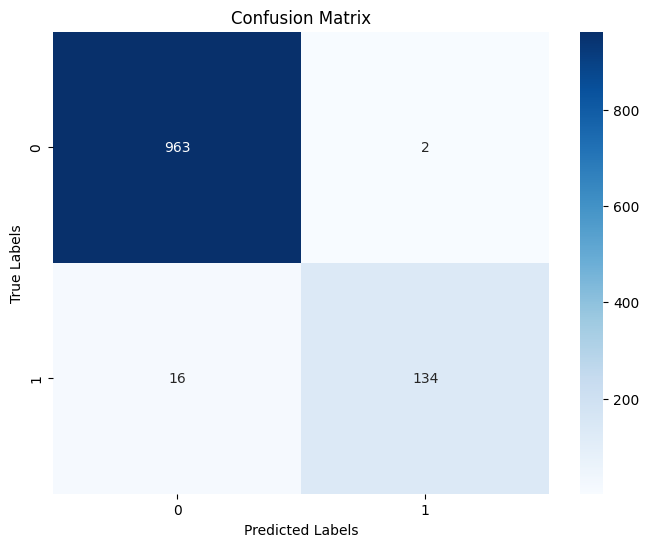

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
cm_matrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# predicting for a custom  message

In [36]:
# using a random spam msg and checking
custom_message=['Congratulations! You’ve won a $1000 gift card!']
custom_vector=vectorizer.transform(custom_message)
prediction=model.predict(custom_vector)

In [37]:
if prediction[0]==0:
  print('Not Spam')
else:
  print("Spam")

Spam


 ## CONCLUSION
 The analysis shows the potential of using Multinomial Naive Bayers Algo for this project prediction. The modle has achieved an accuracy of 98.39% indiciating a great percentage of the overall of its predictions on selected features .The confusion Matrix shows that the type of errors it makes .

 A testing spam msg was used to test if it works properly and after giving the neccesary dataset and trainig it was able to predict that it is spam correctly.